In [16]:
from cosipy.util import fetch_wasabi_file
# dependencies for response
import numpy as np
import astropy.units as u
from astropy.units import Quantity
from astropy.coordinates import SkyCoord, cartesian_to_spherical, Galactic
from astropy.io import fits
from astropy.time import Time
from astropy.table import Table
import matplotlib.pyplot as plt

# dependencies for plotting mollweide projections
from mhealpy import HealpixMap, HealpixBase
import healpy as hp
import pandas as pd
from pathlib import Path

# This is cosi.response
from scoords import Attitude, SpacecraftFrame
from cosipy.response import FullDetectorResponse, DetectorResponse
from cosipy.spacecraftfile import SpacecraftFile
from cosipy import test_data
from histpy import Histogram, HealpixAxis, Axis, Axes
import gc

# This is cosi.BinnedData
from cosipy import BinnedData, UnBinnedData
# this is for fitting and forward folding (#3ML is needed for spectral modeling)
from threeML import Model, Powerlaw
from astromodels import Band


# This is cosi_image_deconvolution
from cosipy.image_deconvolution import SpacecraftAttitudeExposureTable, CoordsysConversionMatrix
from cosipy.ts_map.TSMap import TSMap

# dependencies for data handling
import shutil
import os
from hashlib import md5

In [ ]:
# ----------------------------------------------------------------------------------------------------------------------------
path_to_Source = "COSI-SMEX/DC3/Data/Sources/"
# Source file
Fe60_Source_file= "60Fe_NE2001_3months_unbinned_data_filtered_with_SAAcut.fits.gz"

# ----------------------------------------------------------------------------------------------------------------------------
path_to_Ori = "COSI-SMEX/DC3/Data/Orientation/"
#oritnation file
ori_file = "DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori"

# ----------------------------------------------------------------------------------------------------------------------------
# response file
response_file_Fe60_high = "Response60FeHigh.o4.e1329_1336.s10201526728102.m1287.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.good_chunks.h5.zip"
response_file_Fe60_low = "Response60FeLow.o4.e1170_1176.s9552269354945.m1188.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.good_chunks.h5.zip"

# ----------------------------------------------------------------------------------------------------------------------------
path_to_bkg= "COSI-SMEX/DC3/Data/Backgrounds/Ge/" 
path_to_bkg_binned= "COSI-SMEX/DC3/Data/Backgrounds/Ge/Binned_BG_Files/"
#background files
albedo_bkg_file = "AlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits.gz"
Fe_high_bkg_file = "Total_BG_3months_binned_for_Fe60High_filtered_with_SAAcut.hdf5"
Fe_low_bkg_file = "Total_BG_3months_binned_for_Fe60Low_filtered_with_SAAcut.hdf5"



# #----------------------------------------------------------------------------------------------------------------------------
# # for some reason the source and bkg file are remained zipped
# # Source file
# fetch_wasabi_file(path_to_Source + Fe60_Source_file, unzip=True, checksum='b0f8c1d2e3a4b5c6d7e8f9a0b1c2d3e4')

# #----------------------------------------------------------------------------------------------------------------------------
# #Background files
# fetch_wasabi_file(file = path_to_bkg + albedo_bkg_file)
# fetch_wasabi_file((path_to_bkg_binned + Fe_high_bkg_file))
# fetch_wasabi_file((path_to_bkg_binned + Fe_low_bkg_file))

# #----------------------------------------------------------------------------------------------------------------------------
# #ONLY RESPONSE FILE ARE UNZIPPED

# #response file
# fetch_wasabi_file("COSI-SMEX/DC3/Data/Responses/" + response_file_Fe60_high)
# fetch_wasabi_file("COSI-SMEX/DC3/Data/Responses/" + response_file_Fe60_low)

# # Use unzip for .zip files, not gunzip
# os.system('unzip -o ' + response_file_Fe60_high)
# os.system('unzip -o ' + response_file_Fe60_low)


# #----------------------------------------------------------------------------------------------------------------------------
# #oritnation file
# fetch_wasabi_file(path_to_Ori + ori_file, checksum='e5e71e3528e39b855b0e4f74a1a2eebe')


data_path = "data/"

# psichi
# 3720

In [3]:
%matplotlib inline

plot = False
#  --------------------------------------------------------------
# 1. Use the BinnedData to load, get unbinned and binned data, and create psichi plots
#  --------------------------------------------------------------
# create BinnedData object with YAML file

source = BinnedData("inputs.yaml")
# this one is used when
source.get_binned_data(unbinned_data = data_path + Fe60_Source_file, psichi_binning="galactic", make_binning_plots=plot, show_plots=plot)

# time_axis = source.binned_data.axes[0]
# time_axis_edges = time_axis.edges
# print(f"Source time binning:")
# print(f"  Number of bins: {len(time_axis_edges)-1}")
# print(f"  Range: {time_axis_edges[0]:.1f} - {time_axis_edges[-1]:.1f}")
# print(f"  Time edges: {time_axis_edges}") 

# energy_axis = source.binned_data.axes[0]
# energy_axis_edges = energy_axis.edges
# print(f"Source energy binning:")
# print(f"  Number of bins: {len(energy_axis_edges)-1}")
# print(f"  Range: {energy_axis_edges[0]:.1f} - {energy_axis_edges[-1]:.1f}")
# print(f"  Energy edges: {energy_axis_edges}") 


# phi_bins = source.binned_data.axes[2]
# phi_axis_edges = phi_bins.edges
# print(f"Source phi binning:")
# print(f"  Number of bins: {len(phi_axis_edges)-1}")
# print(f"  Range: {phi_axis_edges[0]:.1f} - {phi_axis_edges[-1]:.1f}")
# print(f"  phi edges: {phi_axis_edges}") 

# print("[")
# for i in range(60):
#     print(f"{i*3:.1f}," , end="")
# print("}")

In [4]:
#  --------------------------------------------------------------
# 2. Use the BinnedData to load, get unbinned and binned data, and create psichi plots
#  --------------------------------------------------------------
# create BinnedData object with YAML file


binned_bkg = BinnedData("inputs.yaml")
# this one is used when
binned_bkg.load_binned_data_from_hdf5(data_path + Fe_high_bkg_file)

# Get energy axis (axis 1) from background
energy_axis = binned_bkg.binned_data.axes[1]
background_energy_edges = energy_axis.edges

# print(f"Background time binning:")
# print(f"  Number of bins: {len(background_energy_edges)-1}")
# print(f"  Range: {background_energy_edges[0]:.1f} - {background_energy_edges[-1]:.1f} keV")
# print(f"  time edges: {background_energy_edges}")


# energy_axis = binned_bkg.binned_data.axes[0]
# energy_axis_edges = energy_axis.edges
# print(f"Source energy binning:")
# print(f"  Number of bins: {len(energy_axis_edges)-1}")
# print(f"  Range: {energy_axis_edges[0]} - {energy_axis_edges[-1]}")
# print(f"  Energy edges: {energy_axis_edges}") 

# print(1835487300.0  - 1843467255.0) 

# phi_bins = binned_bkg.binned_data.axes[2]
# phi_axis_edges = phi_bins.edges
# print(f"Source phi binning:")
# print(f"  Number of bins: {len(phi_axis_edges)-1}")
# print(f"  Range: {phi_axis_edges[0]:.1f} - {phi_axis_edges[-1]:.1f}")
# print(f"  phi edges: {phi_axis_edges}") 

if plot:
    binned_bkg.plot_binned_data()

# print(source.__dict__)b

In [5]:
signal = source.binned_data.to_dense()  
bkg = binned_bkg.binned_data.to_dense()

event = signal + bkg

In [6]:
signal.write("Fe60_galactic_signal.hdf5", overwrite = True)
bkg.write("Fe60_galactic_bkg.hdf5", overwrite = True)
event.write("Fe60_galactic_event.hdf5", overwrite = True)


In [6]:
signal = Histogram.open("Fe60_galactic_signal.hdf5")
bkg = Histogram.open("Fe60_galactic_bkg.hdf5")
event = Histogram.open("Fe60_galactic_event.hdf5")

In [8]:
response_path = data_path + response_file_Fe60_high.replace(".zip", "")

image_response = FullDetectorResponse.open(response_path)

$\large{\text{Data Reduction}}$

In [9]:
%%time

ori_filepath = data_path + ori_file
ori = SpacecraftFile.parse_from_file(ori_filepath)

CPU times: user 1.73 s, sys: 433 ms, total: 2.17 s
Wall time: 2.09 s


In [12]:
response_path = data_path + response_file_Fe60_high.replace(".zip", "")
image_response = FullDetectorResponse.open(response_path)

nside_local = image_response.nside
npix_local = hp.nside2npix(nside_local)

nside_local, npix_local

(16, 3072)

In [14]:
image_response

FILENAME: '/home/ricekong/cosipy/docs/tutorials/testing/data/Response60FeHigh.o4.e1329_1336.s10201526728102.m1287.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.good_chunks.h5'
AXES:
  NuLambda:
    DESCRIPTION: 'Location of the simulated source in the spacecraft coordinates'
    TYPE: 'healpix'
    NPIX: 3072
    NSIDE: 16
    SCHEME: 'RING'
  Ei:
    DESCRIPTION: 'Initial simulated energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 1
    EDGES: [1329.0 keV, 1336.0 keV]
  Em:
    DESCRIPTION: 'Measured energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 1
    EDGES: [1329.0 keV, 1336.0 keV]
  Phi:
    DESCRIPTION: 'Compton angle'
    TYPE: 'linear'
    UNIT: 'deg'
    NBINS: 60
    EDGES: [0.0 deg, 3.0 deg, 6.0 deg, 9.0 deg, 12.0 deg, 15.0 deg, 18.0 deg, 21.0 deg, 24.0 deg, 27.0 deg, 30.0 deg, 33.0 deg, 36.0 deg, 39.0 deg, 42.0 deg, 45.0 deg, 48.0 deg, 51.0 deg, 54.0 deg, 57.0 deg, 60.0 deg, 63.0 deg, 66.0 deg, 69.0 deg, 72.0 deg, 75.0 deg, 78.0 deg, 81.0 deg, 84.0 deg, 

In [17]:
%%time

nside_scatt = nside_local

exposure_table = SpacecraftAttitudeExposureTable.from_orientation(ori, nside = nside_scatt, start = None, stop = None)
exposure_table

  0%|          | 0/531997 [00:00<?, ?it/s]

CPU times: user 11.4 s, sys: 718 ms, total: 12.1 s
Wall time: 11.6 s


,scatt_binning_index,healpix_index,zpointing,xpointing,zpointing_averaged,xpointing_averaged,delta_time,exposure,num_pointings,bkg_group
0,0,"(2340, 182)","[[22.574117544763574, -31.110730874676822], [2...","[[22.574117544763574, 58.88926912532318], [22....","[22.53186598336207, -31.00790853492029]","[22.534830601784506, 58.99233544039963]","[15.000000000002345, 15.000000000002345, 15.00...",18630.0,1242,0
1,1,"(2340, 222)","[[22.890562060304546, -31.881626976766405], [2...","[[22.890562060304546, 58.1183730232336], [23.2...","[23.25825698290161, -32.7823975777024]","[23.263880268626753, 57.2180802358068]","[14.999999999992752, 15.000000000002345, 15.00...",26010.0,1734,0
2,2,"(2340, 267)","[[23.840879977830582, -34.19868307024379], [23...","[[23.84087997783058, 55.80131692975622], [23.7...","[23.77880720067148, -34.04202634110881]","[23.77903257452164, 55.95800335215191]","[15.000000000002345, 15.000000000002345, 14.99...",5655.0,377,0
3,3,"(2404, 267)","[[24.158420899721513, -34.97241501346041], [24...","[[24.158420899721506, 55.027584986539594], [24...","[24.449149312358237, -35.6831019120271]","[24.459250728663985, 54.3178648092337]","[14.999999999992752, 15.000000000002345, 15.00...",35490.0,2366,0
4,4,"(2404, 315)","[[25.11519953479184, -37.297431342520845], [25...","[[25.115199534791838, 52.70256865747916], [25....","[25.301677686085025, -37.75081792048012]","[25.30377989506407, 52.2493856987317]","[15.000000000002345, 14.999999999992752, 15.00...",16230.0,1082,0
...,...,...,...,...,...,...,...,...,...,...
3091,3091,"(113, 899)","[[18.856258361961434, 64.17240568347188]]","[[198.8562583619614, 25.82759431652813]]","[18.85625836196143, 64.17240568347188]","[198.85625836196138, 25.827594316528135]",[15.000000000002345],15.0,1,0
3092,3092,"(484, 395)","[[24.366312246878625, 42.187500311034995]]","[[204.36631224687858, 47.812499688965005]]","[24.36631224687862, 42.187500311035]","[204.36631224687858, 47.812499688965005]",[15.000000000002345],15.0,1,0
3093,3093,"(548, 395)","[[23.19419869123921, 40.821622250446495]]","[[203.1941986912392, 49.17837774955349]]","[23.194198691239215, 40.821622250446495]","[203.19419869123917, 49.1783777495535]",[15.000000000002345],15.0,1,0
3094,3094,"(675, 201)","[[15.800124514097567, 31.086159136641342]]","[[195.80012451409755, 58.913840863358665]]","[15.800124514097567, 31.086159136641342]","[195.80012451409755, 58.91384086335866]",[15.000000000002345],15.0,1,0


In [18]:
exposure_table.save_as_fits("exposure_table_dc2.fits", overwrite = True)

In [21]:
map_pointing_zx = exposure_table.calc_pointing_trajectory_map()
map_pointing_zx = map_pointing_zx.to_dense()

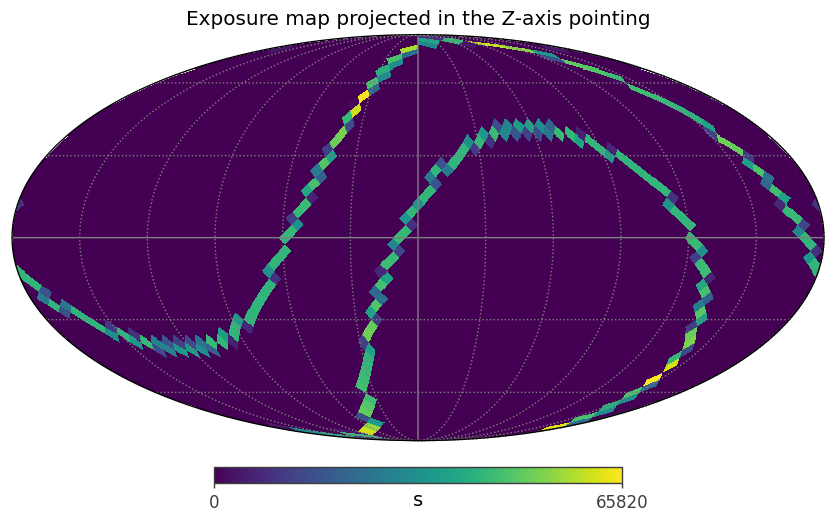

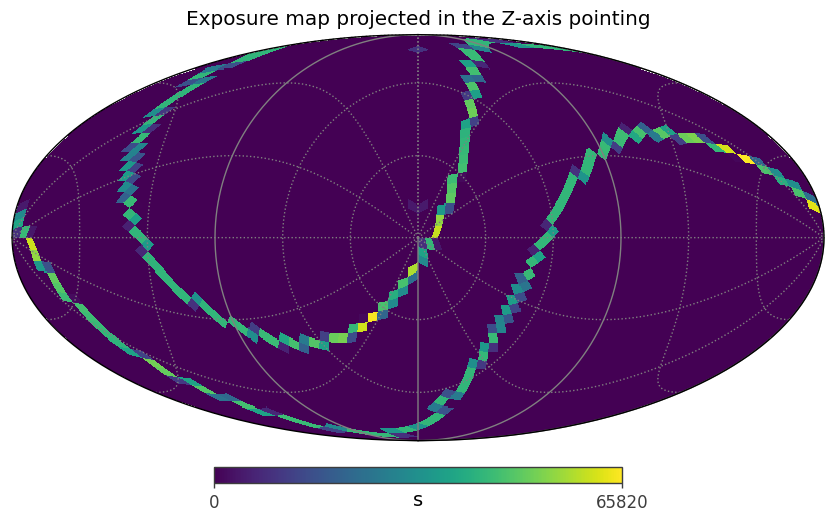

In [22]:
hp.mollview(map_pointing_zx.project('z').contents, rot=(0,0), unit = u.s, title = "Exposure map projected in the Z-axis pointing")
hp.graticule(color='gray', dpar = 30)
plt.show()

hp.mollview(map_pointing_zx.project('z').contents, rot=(0,90), unit = u.s, title = "Exposure map projected in the Z-axis pointing")
hp.graticule(color='gray', dpar = 30)
plt.show()

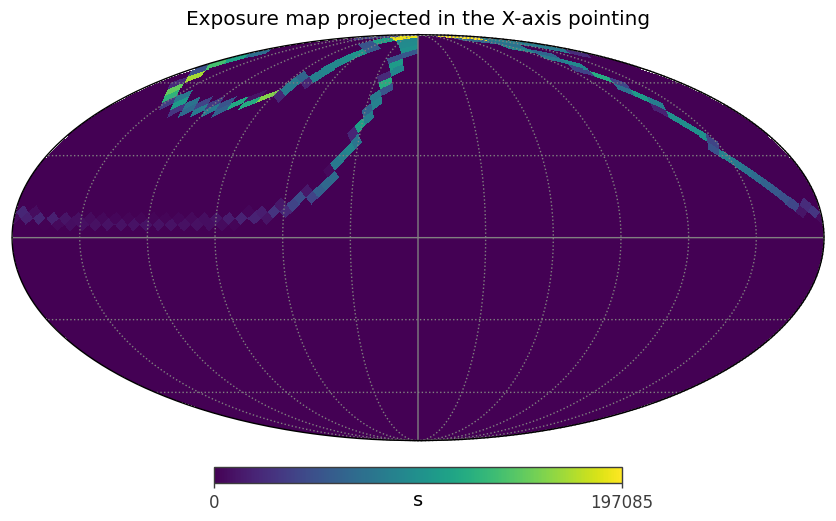

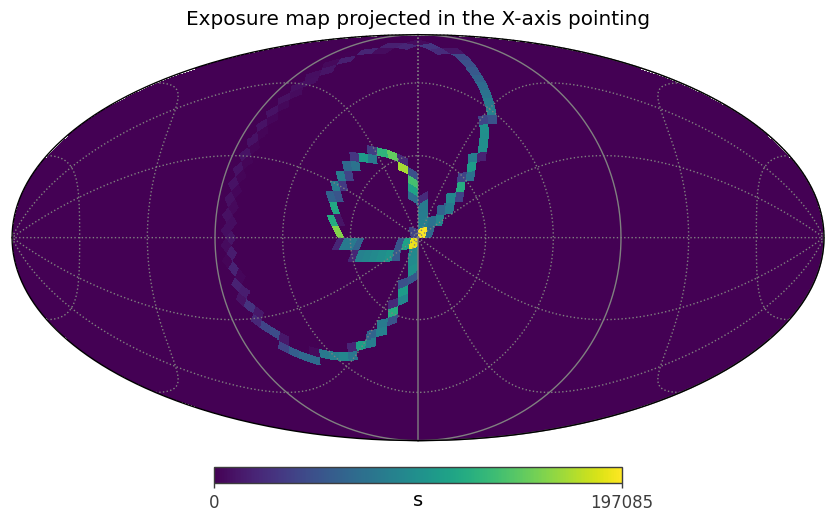

In [23]:
hp.mollview(map_pointing_zx.project('x').contents, rot=(0,0), unit = u.s, title = "Exposure map projected in the X-axis pointing")
hp.graticule(color='gray', dpar = 30)
plt.show()

hp.mollview(map_pointing_zx.project('x').contents, rot=(0,90), unit = u.s, title = "Exposure map projected in the X-axis pointing")
hp.graticule(color='gray', dpar = 30)
plt.show()

In [25]:
%%time

nside_model = nside_local

coordsys_conv_matrix = CoordsysConversionMatrix.spacecraft_attitude_binning_ccm(image_response, exposure_table, nside_model = nside_model, use_averaged_pointing = True)

  0%|          | 0/3096 [00:00<?, ?it/s]

CPU times: user 5h 43min 22s, sys: 13min 3s, total: 5h 56min 26s
Wall time: 6h 1min 12s


In [26]:
coordsys_conv_matrix.write("ccm_dc2.hdf5", overwrite = True)